# Part 1: Simulation Pipeline for scRNA-seq Data with scDesign3
# Project Overview
This notebook implements the simulation pipeline for the mini-project "Simulating single-cell RNA-seq data with scDesign3". The workflow includes:
Loading PBMC3K reference data;
Fitting scDesign3 model to capture gene-cell type dependencies;
Generating synthetic datasets with varying DC cell proportions;
Creating downsampled versions with different sequencing depths.



In [2]:
# Setup and Load Libraries
library(Seurat)
library(SeuratData)
library(SingleCellExperiment)
library(scDesign3)

# ============================================
# 1. Load and Prepare PBMC3K Reference Data
# ============================================

# Load the PBMC3K dataset
data("pbmc3k")
pbmc3k <- UpdateSeuratObject(pbmc3k)

# Convert to SingleCellExperiment
sce <- as.SingleCellExperiment(pbmc3k)

# Rename cell type column for easy access
colData(sce)$cell_type <- colData(sce)$seurat_annotations

# Select top 1500 highly variable genes to reduce dimensionality
pbmc3k <- FindVariableFeatures(pbmc3k, nfeatures = 1500)
hvg_genes <- VariableFeatures(pbmc3k)
sce_subset <- sce[hvg_genes, ]

Loading required package: SeuratObject

Loading required package: sp


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t


── Installed datasets ──────────────────────────────── SeuratData v0.2.2.9002 ──

✔ pbmc3k 3.1.4                          


────────────────────────────────────── Key ─────────────────────────────────────

✔ Dataset loaded successfully
❯ Dataset built with a newer version of Seurat than installed
❓ Unknown version of Seurat installed


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: 'matrixStats'


The following object is masked from 'package:dplyr':

    count



Attaching package: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQR

In [ ]:
# ============================================
# 2. Fit scDesign3 Model
# ============================================

# The actual computation was performed separately in RStudio and the related parameters were saved as .rds files. 
# The following part only shows codes, and the results for analysis will be imported from existing .rds files.

fitted_model <- scdesign3(
    sce = sce_subset,
    assay_use = "counts",
    celltype = "cell_type",
    mu_formula = "cell_type",      
    other_covariates = NULL,
    sigma_formula = "1",          
    corr_formula = "1",            
    family_use = "nb",           
    n_cores = 4,
    copula = "gaussian",           
    return_model = TRUE,
    nonzerovar = TRUE,
    DT = TRUE
)

In [ ]:
# ============================================
# 3. Generate Datasets with Varying DC Proportions
# ============================================

# Extract model parameters for simulation
my_marginal <- fitted_model$marginal_list

# Fit copula for correlation structure
my_copula <- fit_copula(
  sce = sce_subset,
  assay_use = "counts",
  marginal_list = my_marginal,
  family_use = "nb",
  copula = "gaussian",
  n_cores = 4,
  input_data = counts(sce_subset)
)

# Function to generate data with specified DC proportion
generate_data <- function(dc_ratio, n_total = 3000) {
  
  # Original cell type proportions (excluding DC for baseline)
  original_props <- prop.table(table(sce_subset$cell_type))
  dc_name <- "DC"
  other_types <- names(original_props)[names(original_props) != dc_name]
  other_ratios <- original_props[other_types] / sum(original_props[other_types])
  
  # Construct new cell type labels
  n_dc <- max(1, round(n_total * dc_ratio))
  new_cell_types <- c(
    rep(dc_name, n_dc),
    sample(other_types, n_total - n_dc, replace = TRUE, prob = other_ratios)
  )
  
  new_covariate <- data.frame(
    cell_type = new_cell_types,
    row.names = paste0("cell_", 1:n_total)
  )
  
  # Extract parameters for new covariate
  my_para <- extract_para(
    sce = sce_subset,
    marginal_list = my_marginal,
    n_cores = 4,
    family_use = "nb",
    new_covariate = new_covariate,
    data = counts(sce_subset)
  )
  
  # Generate synthetic counts
  sim_counts <- simu_new(
    mean_mat = my_para$mean_mat,
    sigma_mat = my_para$sigma_mat,
    zero_mat = my_para$zero_mat,
    copula_list = my_copula$copula_list,
    family_use = "nb",
    new_covariate = new_covariate
  )
  
  # Return as SingleCellExperiment
  sce_sim <- SingleCellExperiment(
    assays = list(counts = sim_counts),
    colData = new_covariate
  )
  
  return(sce_sim)
}

# Generate three datasets
sce_sim_10pct <- generate_data(0.10)   # 10% DC
sce_sim_1pct  <- generate_data(0.01)   # 1% DC
sce_sim_01pct <- generate_data(0.001)  # 0.1% DC

In [ ]:
# Save datasets
saveRDS(sce_sim_10pct, "simulated_DC_10pct.rds")
saveRDS(sce_sim_1pct, "simulated_DC_1pct.rds")
saveRDS(sce_sim_01pct, "simulated_DC_01pct.rds")

# Save model parameters for future use
saveRDS(my_marginal, "my_marginal.rds")
saveRDS(my_copula, "my_copula.rds")

In [ ]:
# ============================================
# 4. Generate Datasets of Downsampled Versions
# ============================================

# Downsampling function using binomial sampling
downsample_counts <- function(count_matrix, target_frac) {
  
  if (target_frac <= 0 || target_frac > 1) {
    stop("target_frac must be between 0 and 1")
  }
  
  set.seed(123)
  
  downsampled <- matrix(0, 
                        nrow = nrow(count_matrix), 
                        ncol = ncol(count_matrix))
  rownames(downsampled) <- rownames(count_matrix)
  colnames(downsampled) <- colnames(count_matrix)
  
  for (j in 1:ncol(count_matrix)) {
    total_umi <- sum(count_matrix[, j])
    if (total_umi == 0) next
    
    target_umi <- round(total_umi * target_frac)
    if (target_umi > 0) {
      probs <- count_matrix[, j] / total_umi
      downsampled[, j] <- rmultinom(1, target_umi, probs)
    }
  }
  
  return(downsampled)
}

# Create downsampled datasets
depth_fractions <- c(0.50, 0.25)  # 50% and 25% of original depth

generated_datasets <- list()

# For each original dataset
original_datasets <- list(
  "DC_10pct" = sce_10pct,
  "DC_1pct" = sce_1pct,
  "DC_01pct" = sce_01pct
)

for (dc_name in names(original_datasets)) {
  sce_original <- original_datasets[[dc_name]]
  
  # Keep the original 100% depth version
  dataset_name_100 <- sprintf("%s_depth_100pct", dc_name)
  generated_datasets[[dataset_name_100]] <- sce_original
  cat(sprintf("✓ Saved: %s\n", dataset_name_100))
  
  # Generate downsampled versions
  for (depth_frac in depth_fractions) {
    # Create a copy and downsample
    sce_downsampled <- sce_original
    depth_pct <- round(depth_frac * 100)
    
    # Perform downsampling
    counts(sce_downsampled) <- downsample_counts(counts(sce_original), depth_frac)
    
    # Store
    dataset_name <- sprintf("%s_depth_%dpct", dc_name, depth_pct)
    generated_datasets[[dataset_name]] <- sce_downsampled
    
    # Report summary
    original_umi <- sum(counts(sce_original))
    downsampled_umi <- sum(counts(sce_downsampled))
    cat(sprintf("✓ Saved: %s (%.0f%% of original UMIs)\n", 
                dataset_name, 
                100 * downsampled_umi / original_umi))
  }
}

# Create output directory
output_dir <- "simulated_data_downsampled"
if (!dir.exists(output_dir)) {
  dir.create(output_dir)
  cat(sprintf("\nCreated directory: %s\n", output_dir))
}

# Save each dataset
for (name in names(generated_datasets)) {
  filename <- file.path(output_dir, paste0(name, ".rds"))
  saveRDS(generated_datasets[[name]], filename)
}


Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Warning message:
"Assay RNA changing from Assay to Assay"
Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Validating object structure for Assay 'RNA'

Object representation is consistent with the most current Seurat version

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



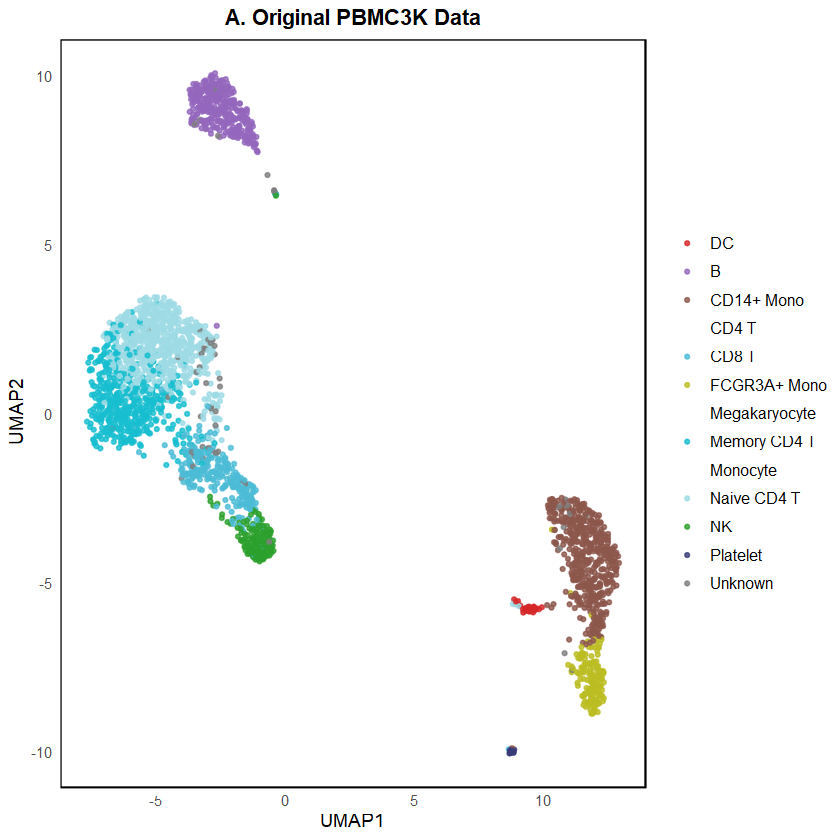

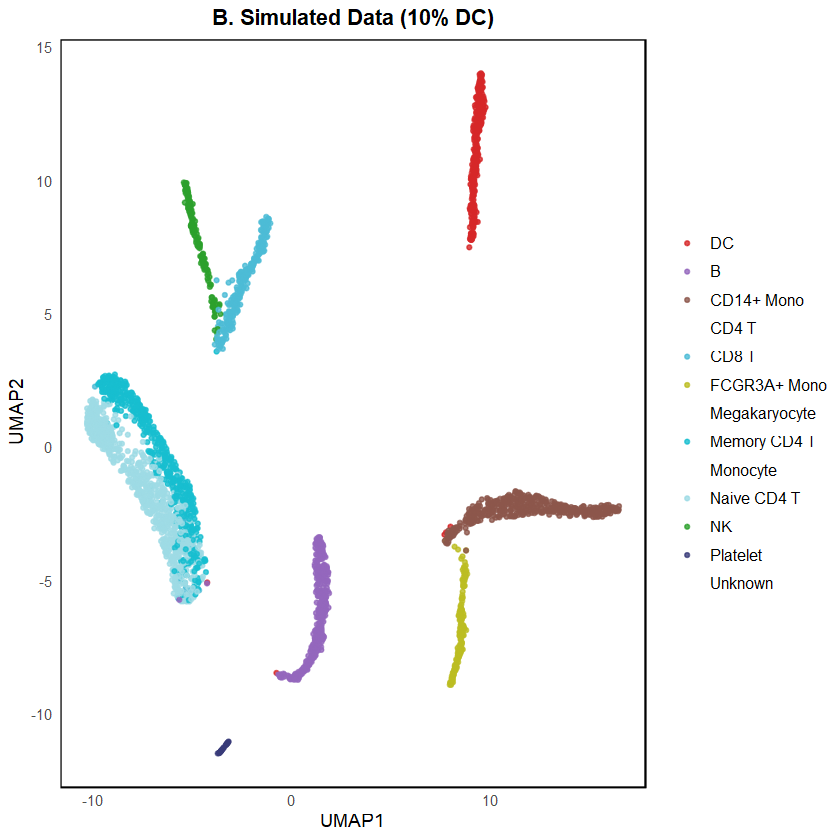

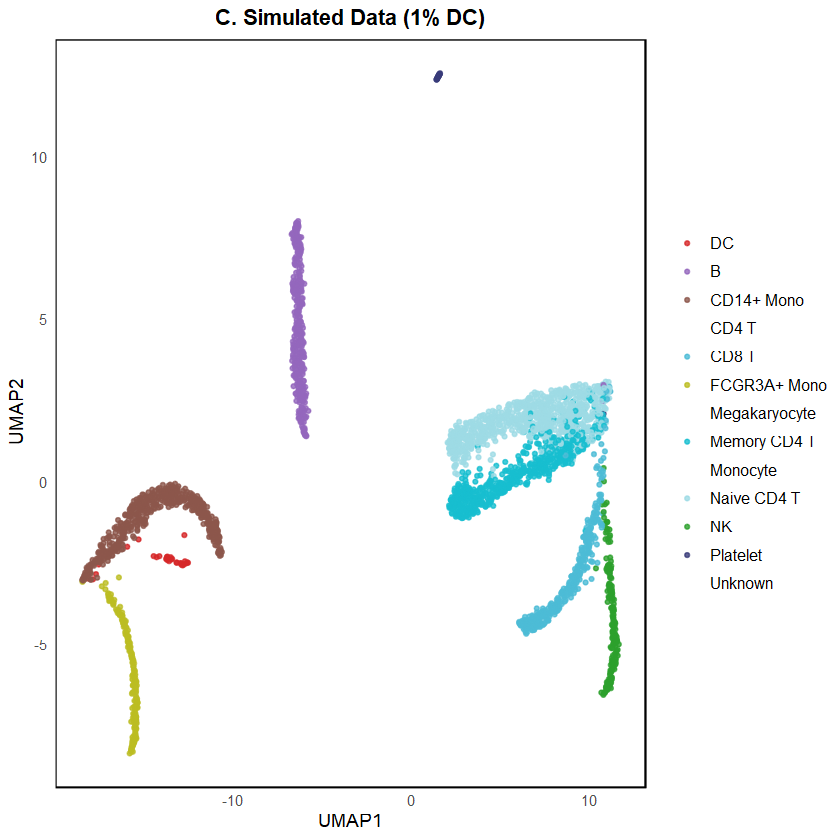


✅ Figure 1 saved (combined and individual)

Fixed color palette used:
                  Cell_Type   Color
DC                       DC #D62728
CD4 T                 CD4 T #1F77B4
CD8 T                 CD8 T #4DBBD5
NK                       NK #2CA02C
B                         B #9467BD
Monocyte           Monocyte #FFD92F
Megakaryocyte Megakaryocyte #E377C2
Unknown             Unknown #7F7F7F
CD14+ Mono       CD14+ Mono #8C564B
FCGR3A+ Mono   FCGR3A+ Mono #BCBD22
Memory CD4 T   Memory CD4 T #17BECF
Naive CD4 T     Naive CD4 T #9EDAE5
Platelet           Platelet #393B79


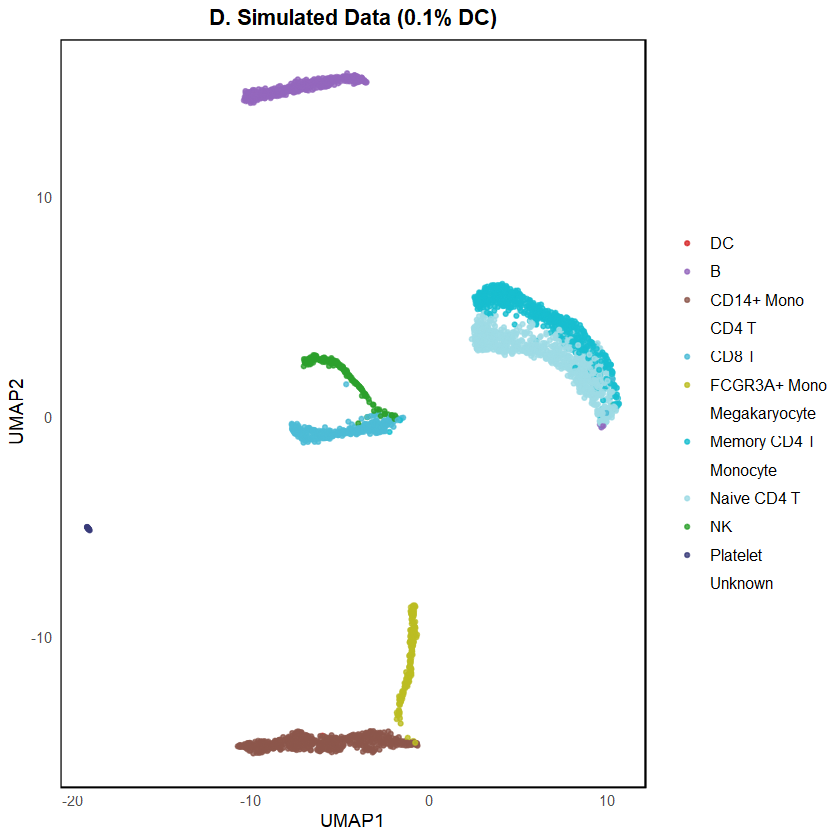

In [ ]:
# ============================================
# Figure 1: UMAP Visualization of Original and Simulated Datasets
# ============================================

setwd('C:/Users/20815/Desktop/CMML2') #Set as your real location that stores .rds files

library(ggplot2)
library(dplyr)
library(Seurat)
library(SeuratData)

# Load original PBMC3K data
data("pbmc3k")
pbmc3k_raw <- UpdateSeuratObject(pbmc3k)

# Load simulated datasets
sce_sim_10pct <- readRDS("simulated_DC_10pct.rds")
sce_sim_1pct <- readRDS("simulated_DC_1pct.rds")
sce_sim_01pct <- readRDS("simulated_DC_01pct.rds")

process_to_seurat <- function(data_obj, dataset_name, is_sce = TRUE) {
  
  if (is_sce) {
    seurat_obj <- CreateSeuratObject(
      counts = counts(data_obj), 
      project = dataset_name,
      meta.data = as.data.frame(colData(data_obj))
    )
  } else {
    seurat_obj <- data_obj
  }
  
  seurat_obj <- NormalizeData(seurat_obj)
  seurat_obj <- FindVariableFeatures(seurat_obj, nfeatures = 1500)
  seurat_obj <- ScaleData(seurat_obj)
  seurat_obj <- RunPCA(seurat_obj, npcs = 30, verbose = FALSE)
  seurat_obj <- FindNeighbors(seurat_obj, dims = 1:20)
  seurat_obj <- FindClusters(seurat_obj, resolution = 0.5, verbose = FALSE)
  seurat_obj <- RunUMAP(seurat_obj, dims = 1:20, verbose = FALSE)
  
  return(seurat_obj)
}

# Process all datasets
seurat_raw <- process_to_seurat(pbmc3k_raw, "Original_PBMC3K", is_sce = FALSE)
seurat_10pct <- process_to_seurat(sce_sim_10pct, "Simulated_10pct_DC")
seurat_1pct <- process_to_seurat(sce_sim_1pct, "Simulated_1pct_DC")
seurat_01pct <- process_to_seurat(sce_sim_01pct, "Simulated_01pct_DC")

fixed_color_palette <- c(
  "DC" = "#D62728",          
  "CD4 T" = "#1F77B4",        
  "CD8 T" = "#4DBBD5",        
  "NK" = "#2CA02C",          
  "B" = "#9467BD",            
  "Monocyte" = "#FFD92F",     
  "Megakaryocyte" = "#E377C2", 
  "Unknown" = "#7F7F7F"      
)

get_all_cell_types <- function(seurat_list) {
  all_types <- c()
  for (obj in seurat_list) {
    if ("cell_type" %in% colnames(obj[[]])) {
      types <- unique(obj$cell_type)
    } else if ("seurat_annotations" %in% colnames(obj[[]])) {
      types <- unique(obj$seurat_annotations)
    } else {
      types <- "Unknown"
    }
    all_types <- c(all_types, as.character(types))
  }
  return(sort(unique(all_types[!is.na(all_types)])))
}

# Get cell types from all datasets
seurat_list <- list(seurat_raw, seurat_10pct, seurat_1pct, seurat_01pct)
all_cell_types <- get_all_cell_types(seurat_list)

# Build complete color palette
complete_color_palette <- fixed_color_palette
for (ct in all_cell_types) {
  if (!(ct %in% names(complete_color_palette))) {
    # Assign next available color from extended palette
    next_idx <- length(complete_color_palette) - length(fixed_color_palette) + 1
    if (next_idx <= length(extended_colors)) {
      complete_color_palette[ct] <- extended_colors[next_idx]
    } else {
      # Fallback: generate random distinct color
      complete_color_palette[ct] <- rgb(runif(1), runif(1), runif(1))
    }
  }
}

# Ensure DC is red
complete_color_palette["DC"] <- "#D62728"

# Reorder legend items (DC first, then alphabetical)
legend_order <- c("DC", sort(setdiff(names(complete_color_palette), "DC")))

# ============================================
# Improved UMAP plotting function with fixed colors and legend
# ============================================

plot_umap_fixed <- function(seurat_obj, title, fixed_colors, legend_order) {
  
  # Extract UMAP coordinates
  umap_df <- as.data.frame(Embeddings(seurat_obj, "umap"))
  colnames(umap_df) <- c("UMAP1", "UMAP2")
  
  # Extract cell type information
  if ("cell_type" %in% colnames(seurat_obj[[]])) {
    umap_df$cell_type <- seurat_obj$cell_type
  } else if ("seurat_annotations" %in% colnames(seurat_obj[[]])) {
    umap_df$cell_type <- seurat_obj$seurat_annotations
  } else {
    umap_df$cell_type <- "Unknown"
  }
  
  umap_df$cell_type <- as.character(umap_df$cell_type)
  umap_df$cell_type[is.na(umap_df$cell_type)] <- "Unknown"
  
  # Convert to factor with fixed order for legend
  umap_df$cell_type <- factor(umap_df$cell_type, levels = legend_order)
  
  # Create plot with larger legend key
  p <- ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = cell_type)) +
    geom_point(size = 0.7, alpha = 0.8) +
    scale_color_manual(
      values = fixed_colors,
      drop = FALSE  # Keep all legend categories even if not present
    ) +
    theme_minimal(base_size = 11) +
    theme(
      panel.grid = element_blank(),
      panel.border = element_rect(fill = NA, color = "black", linewidth = 0.5),
      legend.title = element_blank(),
      legend.position = "right",
      legend.text = element_text(size = 9),
      legend.key.size = unit(0.6, "cm"),  # Larger color points in legend
      legend.spacing.y = unit(0.2, "cm"),
      plot.title = element_text(hjust = 0.5, face = "bold", size = 13)
    ) +
    labs(title = title, x = "UMAP1", y = "UMAP2")
  
  return(p)
}

# Generate all four UMAP plots with fixed colors
p_raw <- plot_umap_fixed(seurat_raw, "A. Original PBMC3K Data", 
                         complete_color_palette, legend_order)
p_10 <- plot_umap_fixed(seurat_10pct, "B. Simulated Data (10% DC)", 
                        complete_color_palette, legend_order)
p_1 <- plot_umap_fixed(seurat_1pct, "C. Simulated Data (1% DC)", 
                       complete_color_palette, legend_order)
p_01 <- plot_umap_fixed(seurat_01pct, "D. Simulated Data (0.1% DC)", 
                        complete_color_palette, legend_order)

# Display plots individually
print(p_raw)
print(p_10)
print(p_1)
print(p_01)

# ============================================
# Optional: Combine all four plots into one figure
# ============================================

library(patchwork)

# Combine with shared legend
combined_plot <- (p_raw + p_10) / (p_1 + p_01) +
  plot_annotation(
    title = "Figure 1: UMAP Visualization of Original and Simulated PBMC3K Datasets",
    subtitle = "scDesign3 successfully preserves cell type structure across varying DC proportions",
    theme = theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
      plot.subtitle = element_text(hjust = 0.5, size = 10)
    )
  ) &
  theme(legend.position = "bottom")

# Save combined figure
ggsave("Figure1_UMAP_Combined.pdf", combined_plot, width = 12, height = 10)
ggsave("Figure1_UMAP_Combined.png", combined_plot, width = 12, height = 10, dpi = 300, bg = "white")

# Also save individual plots
ggsave("Figure1A_Original_UMAP.pdf", p_raw, width = 7, height = 6)
ggsave("Figure1B_10pct_UMAP.pdf", p_10, width = 7, height = 6)
ggsave("Figure1C_1pct_UMAP.pdf", p_1, width = 7, height = 6)
ggsave("Figure1D_01pct_UMAP.pdf", p_01, width = 7, height = 6)

cat("\n✅ Figure 1 saved (combined and individual)\n")
cat("\nFixed color palette used:\n")
print(data.frame(
  Cell_Type = names(complete_color_palette),
  Color = complete_color_palette
))